In [113]:
import numpy as np
import matplotlib.pyplot as plt
import math
%matplotlib inline

In [ ]:
# Basic Hyperparameters

N = 2 # Number of Coins
p = 0.5 # Bias probability
k = 1 # Number of flips
total = 10000 # Number of draws from the probability distribution
state = np.zeros((2**N))
state

array([0., 0., 0., 0.])

In [ ]:
# Setting the inital state as per our use case

state[0] = 1
state

array([1., 0., 0., 0.])

In [ ]:
# Creating the rotation matrix for one coin
theta = 2*math.acos(math.sqrt(p))
R = np.array([
    [math.cos(k*theta/2), -math.sin(k*theta/2)],
    [math.sin(k*theta/2),    math.cos(k*theta/2)]
])

In [117]:
# Finding the final rotation matrix for N coins

T = R.copy()
for i in range(N-1):
    T = np.kron(T,R)

In [118]:
# Flipping the coins

state = T @ state

In [119]:
# Running the RNG

num_list = []
probs = np.square(state)
for i in range(total):
    chosen = np.random.choice([i for i in range(2**N)], size=1, p=probs, replace=False)
    num_list.append(chosen[0])

In [120]:
unique_elements, counts = np.unique(num_list, return_counts=True)

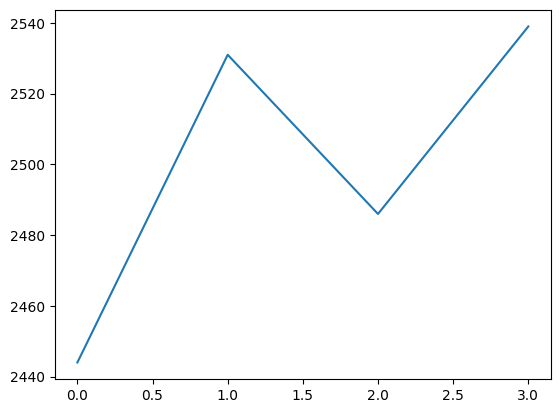

In [121]:
plt.plot(unique_elements,counts)

In [126]:
counts

array([2444, 2531, 2486, 2539])

In [129]:
TS = sum([(c - 2500)**2/2500 for c in counts])
TS

np.float64(2.3256)

In [122]:
# Calculating the EV and Variance

mean = np.mean(num_list)
var = np.var(num_list)


In [123]:
mean, var

(np.float64(1.512), np.float64(1.2464560000000002))

In [124]:
# Theoretical Values:

mean_t = 3*(1-p)
var_t = 5*p*(1-p)

In [125]:
mean_t, var_t

(1.5, 1.25)